In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "8" # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = "8" # export OPENBLAS_NUM_THREADS=4 
os.environ["MKL_NUM_THREADS"] = "8" # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = "8" # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = "8" # export NUMEXPR_NUM_THREADS=6

In [ ]:
import cfa
from cfa import factor, consensus
import tensorly as tl
import numpy as np
import pandas as pd

In [6]:
suffix = "_filtered_hsc"
bc = pd.read_csv(f"../data/preprocessed{suffix}/barcodes.csv", index_col=0).iloc[:, 0]
timepoints = pd.read_csv(f"../data/preprocessed{suffix}/timepoints.csv", index_col=0).iloc[:, 0]
celltypes = pd.read_csv(f"../data/preprocessed{suffix}/celltypes.csv", index_col=0).iloc[:, 0]

In [7]:
rna_variance = 0.8
rna_variance_str = f"{rna_variance:.2f}"

In [8]:
X_rna = pd.read_csv(f"../data/preprocessed{suffix}/X_rna_variance_{rna_variance_str}.csv", index_col=0)
X_adt = pd.read_csv(f"../data/preprocessed{suffix}/X_adt.csv", index_col=0)
X_bc = np.load(f"../data/preprocessed{suffix}/X_bc.npy")

In [9]:
X_rna.shape, X_bc.shape, X_adt.shape

((112, 4787), (112, 5, 8), (112, 163))

In [10]:
import pickle
import glob
import re
from tqdm import tqdm
files = glob.glob(f"../jobs/*_variance_{rna_variance_str}_*_srand_42.pkl")
k_vals = [int(re.split("_|\.", f)[10]) for f in files]

losses = []

for i in tqdm(range(len(files))):
    with open(files[i], "rb") as f:
        res = pickle.load(f)
        obj = np.mean([m.trace[-1] for m in res['cfm'].models])
        losses += [obj, ]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:03<00:00,  8.78it/s]


Text(0, 0.5, 'Mean loss')

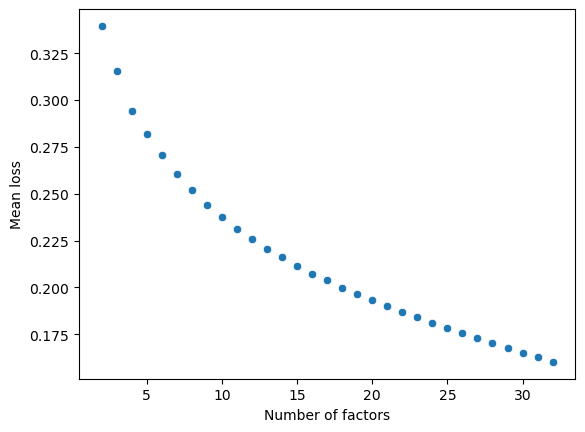

In [11]:
import seaborn as sb
import matplotlib.pyplot as plt
sb.scatterplot(x=k_vals, y=losses)
plt.xlabel("Number of factors")
plt.ylabel("Mean loss")

In [12]:
idx = np.where(np.array(k_vals) == 16)[0][0]
with open(files[idx], 'rb') as f: res=pickle.load(f)
cfm = res['cfm']
fa_cons = res['fa_cons']

In [13]:
import sklearn as sk
dimred_op = sk.decomposition.PCA()
y = dimred_op.fit_transform(cfm.factor_aggregate.T)

<Axes: >

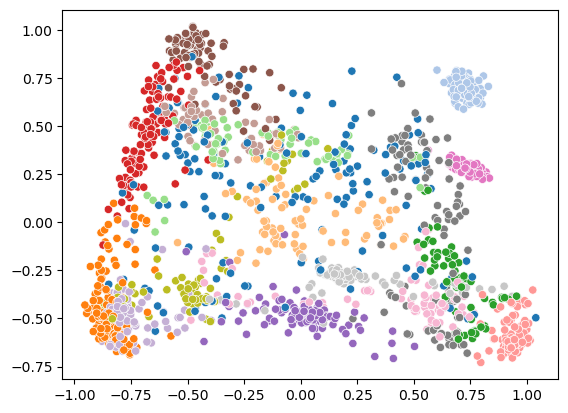

In [14]:
import seaborn as sb
sb.scatterplot(x = y[:, 0], y = y[:, 1], hue = cfm.factor_clusts, palette = "tab20", legend = False)

In [15]:
import copy
consensus_factors = {k : np.vstack([cfm.cons_factors[i][k] for i in range(fa_cons.k)]).T for k in cfm.factor_keys}

In [16]:
np.mean([m.trace[-1] for m in cfm.models])

0.20745328706256883

In [17]:
fa_cons.activities.sum(0)

array([0.16460476, 0.36265118, 0.21884672, 0.22105029, 0.24004806,
       0.19479647, 0.18380547, 0.16816881, 0.28799258, 0.24199843,
       0.19010409, 0.1612289 , 0.19629274, 0.17645323, 0.17951996,
       0.27693354])

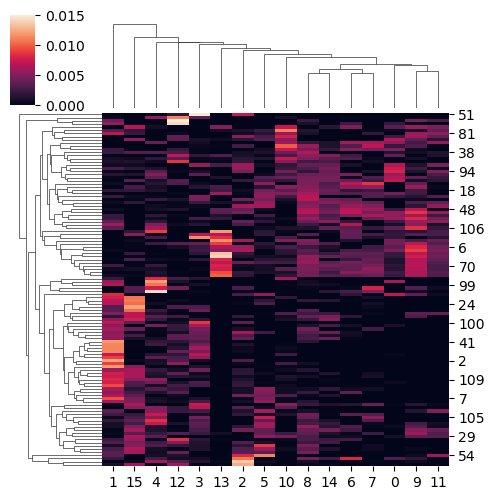

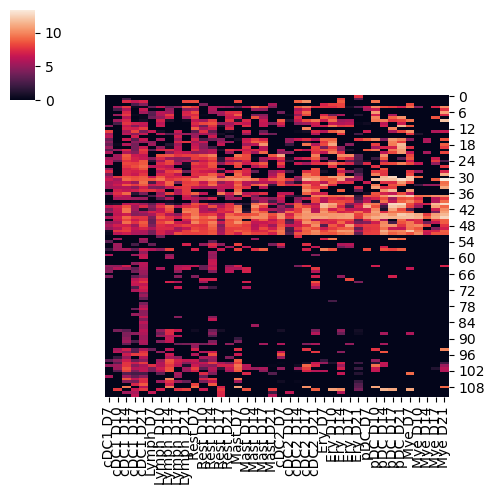

In [18]:
cg = sb.clustermap(fa_cons.activities, figsize = (5, 5))
import itertools
ylab=[f"{x} {y}" for (x, y) in list(itertools.product(list(celltypes), list(timepoints)))]
sb.clustermap(pd.DataFrame(X_bc[cg.dendrogram_row.reordered_ind, :].reshape(X_bc.shape[0],-1), columns = ylab), xticklabels = True, figsize = (5, 5), row_cluster = False, col_cluster = False)

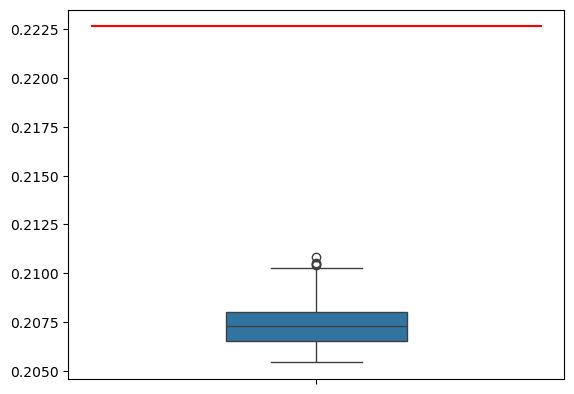

In [20]:
import matplotlib.pyplot as plt
sb.boxplot([m.trace[-1] for m in cfm.models])
plt.hlines(fa_cons.trace[-1], -1, 1, color = "red")

In [21]:
X_rna.shape

(112, 4787)

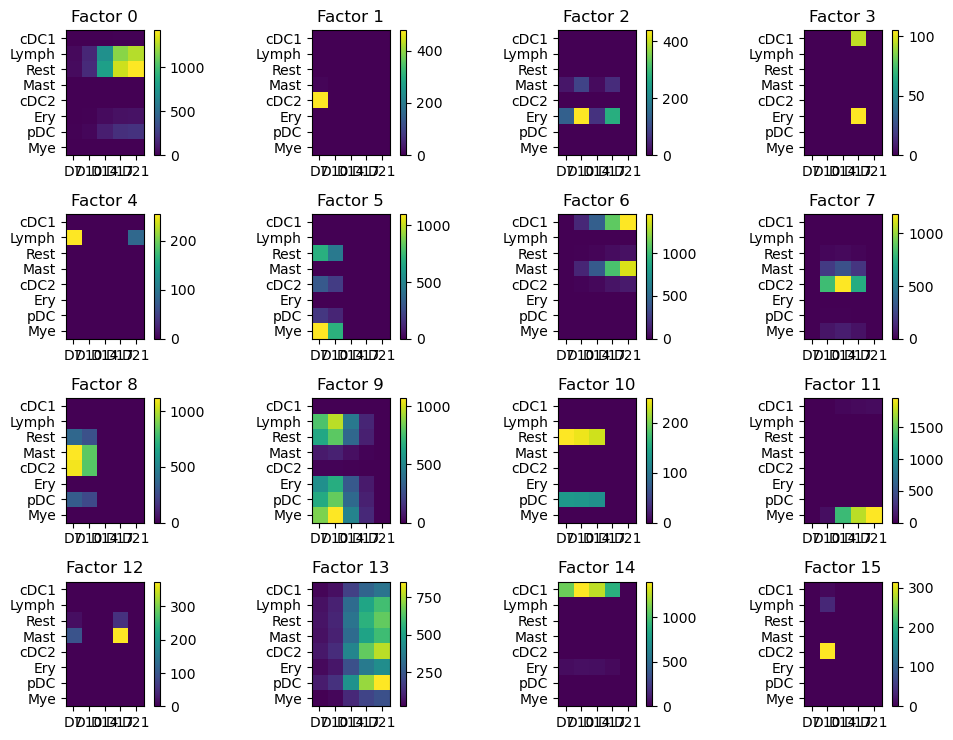

In [96]:
plt.figure(figsize = (10, 7.5))
for i in range(cfm.k):
    plt.subplot(4, 4, i+1)
    plt.imshow((consensus_factors["Vb_0"][:, i].reshape(-1, 1) @ consensus_factors["Vb_1"][:, i].reshape(1, -1)).T)
    plt.colorbar()
    plt.title(f"Factor {i}")
    plt.yticks(range(len(celltypes)), celltypes)
    plt.xticks(range(len(timepoints)), timepoints)
plt.tight_layout()
plt.savefig(os.path.join("./", f"U_factors{suffix}.pdf"))
plt.show()

In [97]:
import sknetwork as skn
import umap
from sklearn.neighbors import NearestNeighbors
import ot
X_latent_umap = umap.UMAP(metric = 'cosine', n_neighbors = 15, min_dist = 0.95, random_state = 1).fit_transform(fa_cons.activities)
C = ot.utils.dist(fa_cons.activities, metric = "cosine"); np.fill_diagonal(C, np.inf)
M = ot.smooth.smooth_ot_dual(np.ones(fa_cons.activities.shape[0]), np.ones(fa_cons.activities.shape[0]), C, 1.0)
lv = skn.clustering.louvain.Louvain(resolution = 1, random_state = 42)
clusts = lv.fit_predict(M);

/data/gpfs/projects/punim0638/stephenz/envs/sis/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Text(0.5, 1.0, 'Clone clusters: latent UMAP')

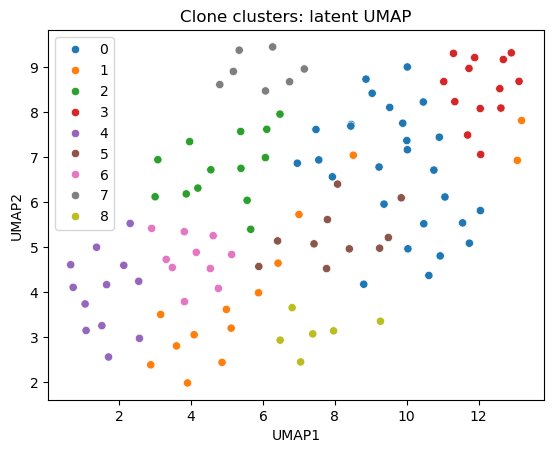

In [98]:
sb.scatterplot(x = X_latent_umap[:, 0], y = X_latent_umap[:, 1], hue = pd.Categorical([str(x) for x in clusts]))
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title("Clone clusters: latent UMAP")

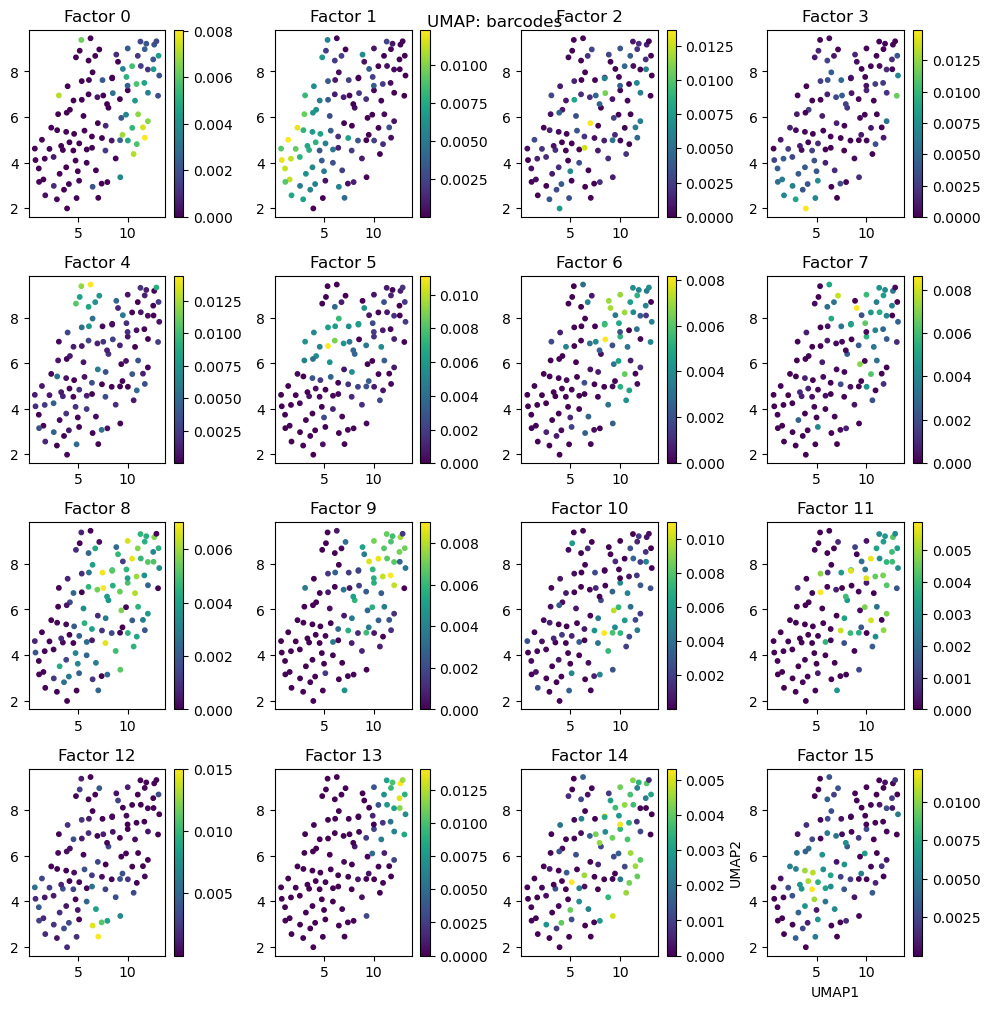

In [99]:
plt.figure(figsize = (10, 10))
for i in range(cfm.k):
    plt.subplot(4, 4, i+1)
    plt.scatter(X_latent_umap[:, 0], X_latent_umap[:, 1], c = fa_cons.activities[:, i], alpha = 1, s = 10)
    plt.colorbar()
    plt.title(f"Factor {i}")
plt.tight_layout()
plt.suptitle("UMAP: barcodes")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
# plt.savefig(os.path.join(FIG_DIR, "bc_activities_umap.pdf"))
plt.show()

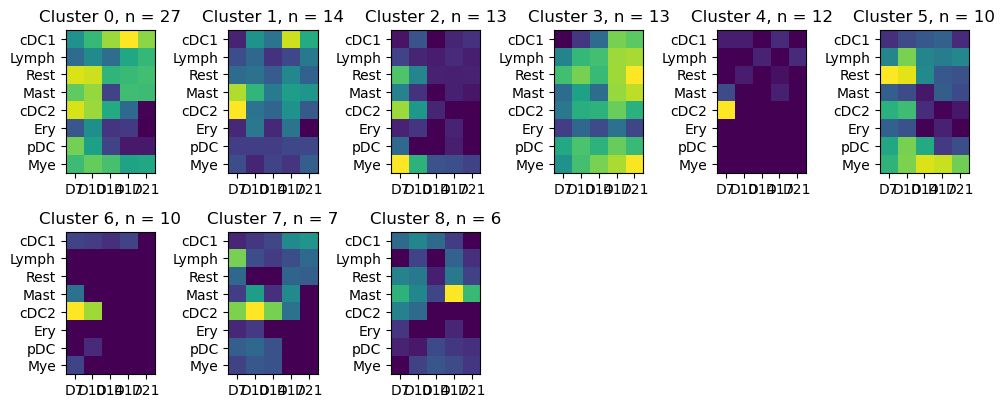

In [100]:
plt.figure(figsize = (10, 10))
for cluster_idx in range(len(np.unique(clusts))):
    plt.subplot(5, 6, cluster_idx+1)
    plt.imshow(X_bc[clusts == cluster_idx, :, :].mean(0).T)
    plt.yticks(range(len(celltypes)), celltypes)
    plt.xticks(range(len(timepoints)), timepoints)
    plt.title(f"Cluster {cluster_idx}, n = {(clusts == cluster_idx).sum()}")
plt.tight_layout()
# plt.savefig(os.path.join(FIG_DIR, "barcode_fate_avg_louvain_cluster_all.pdf"))
plt.show()

In [50]:
fa_cons.factors["Ve"].shape

(4787, 16)

In [51]:
X_rna.shape

(112, 4787)

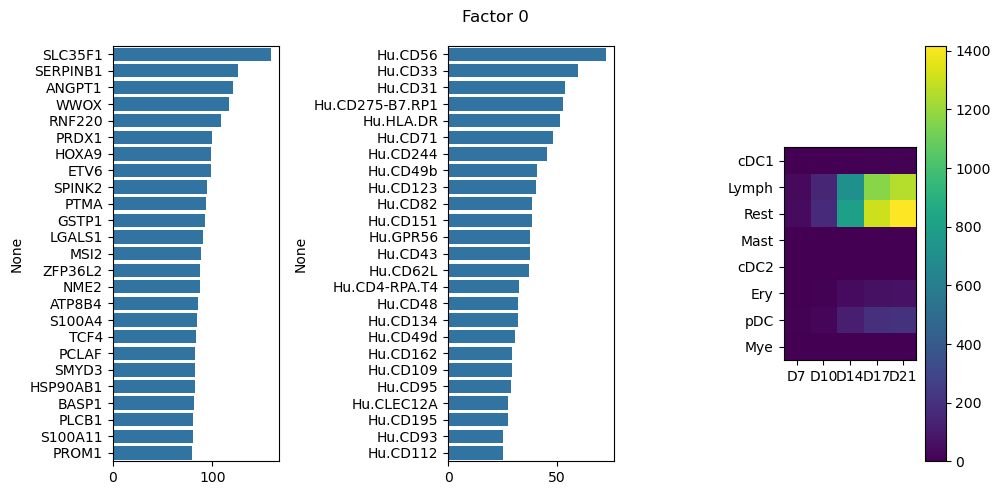

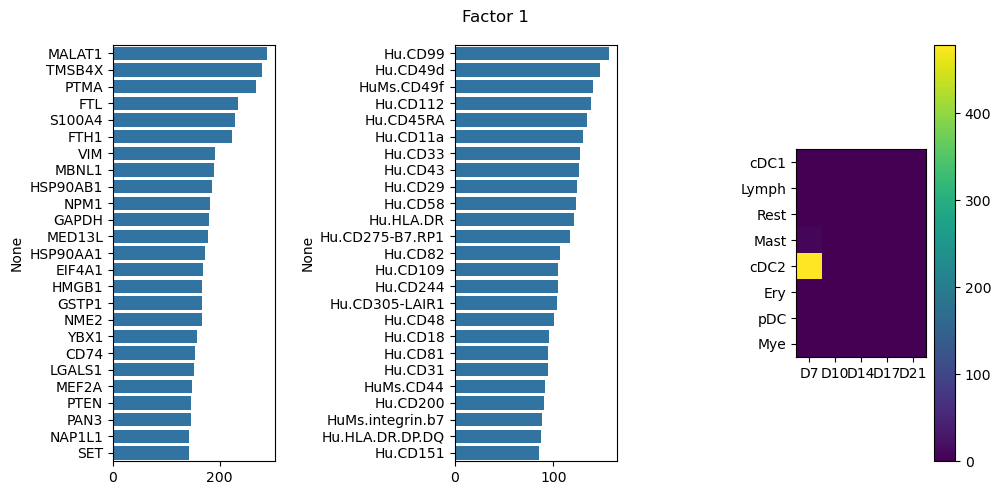

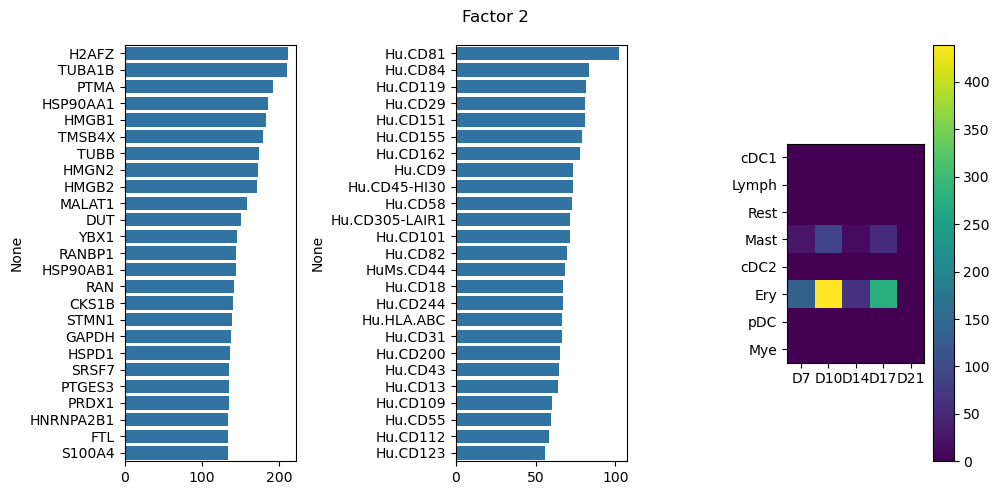

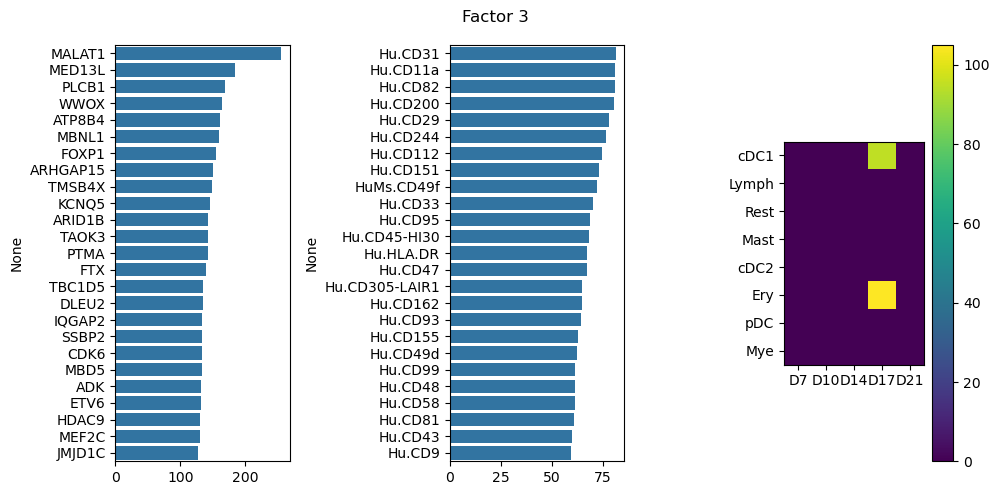

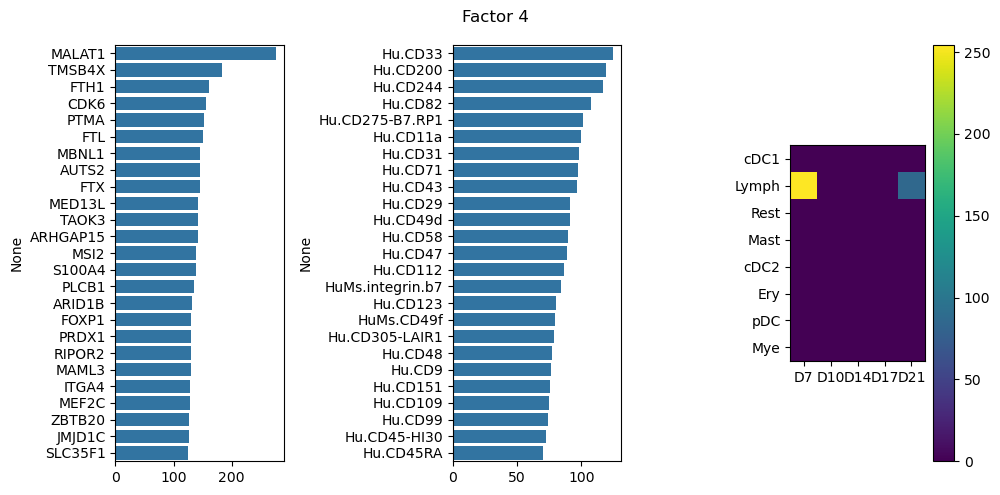

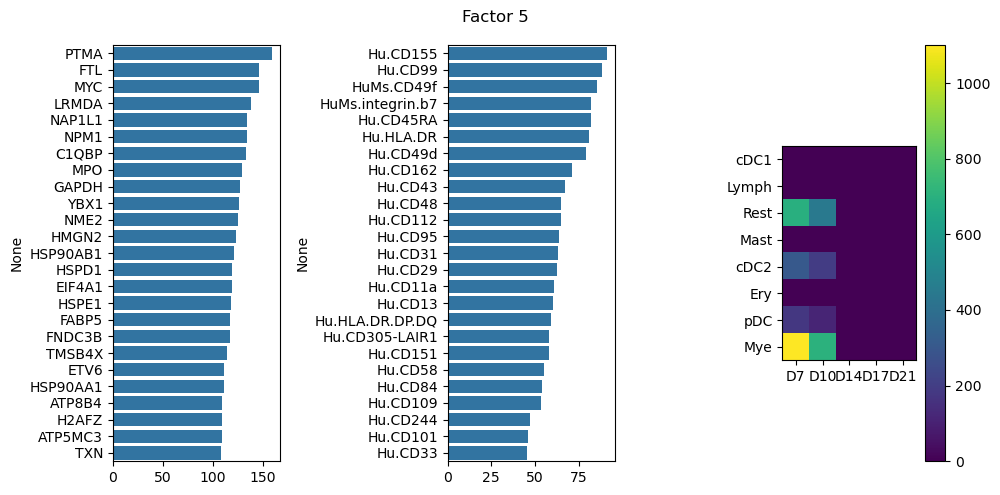

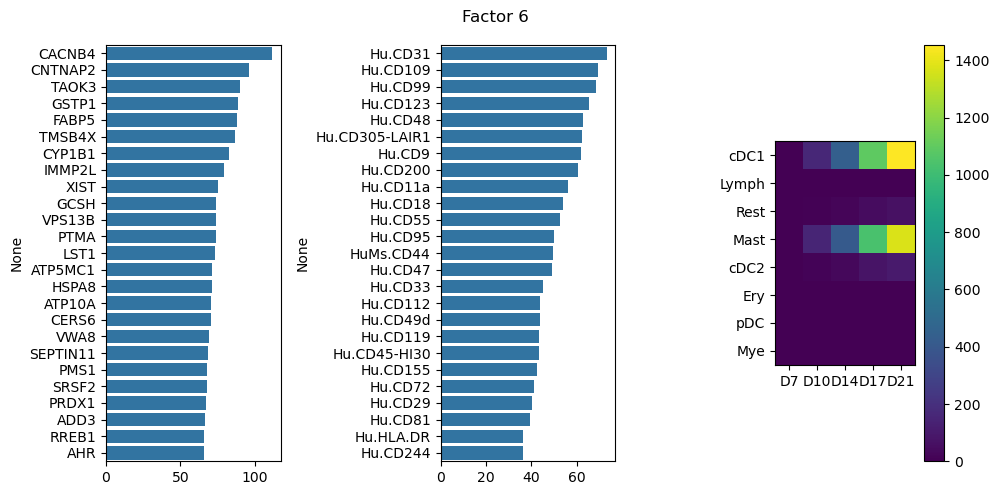

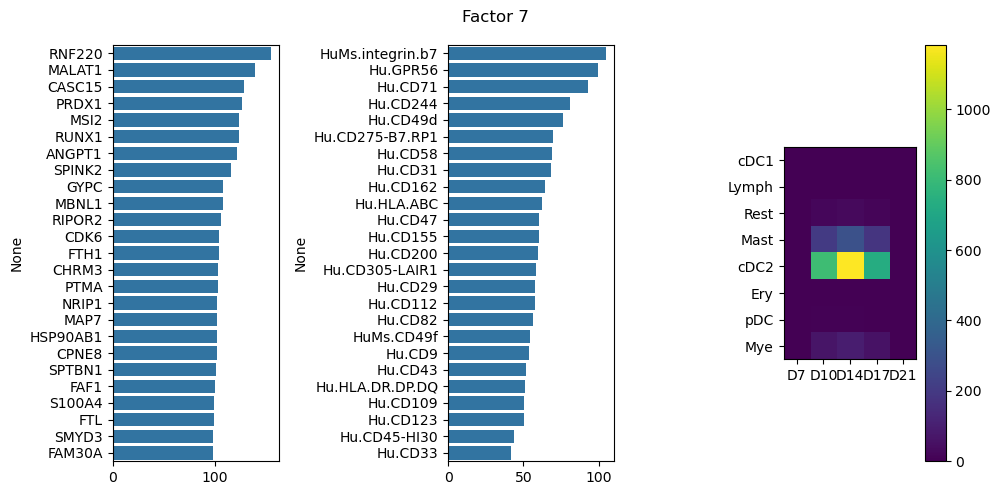

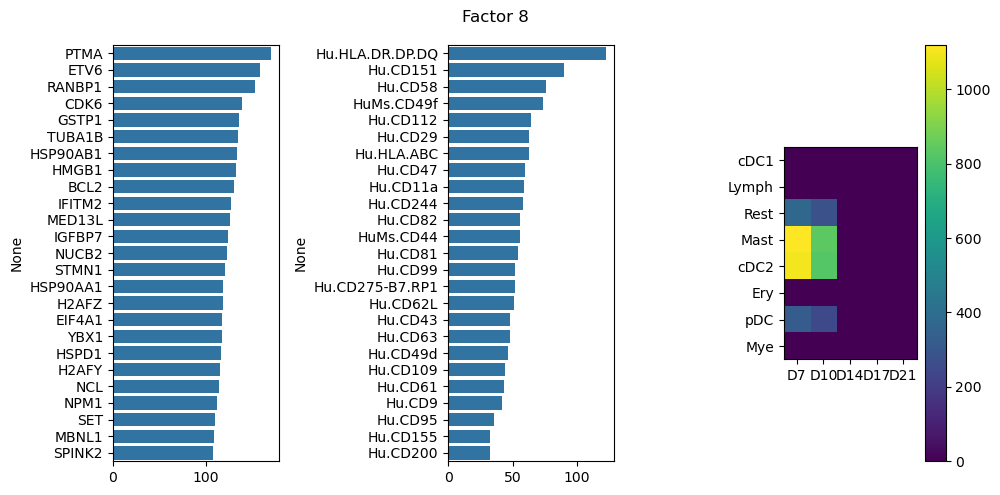

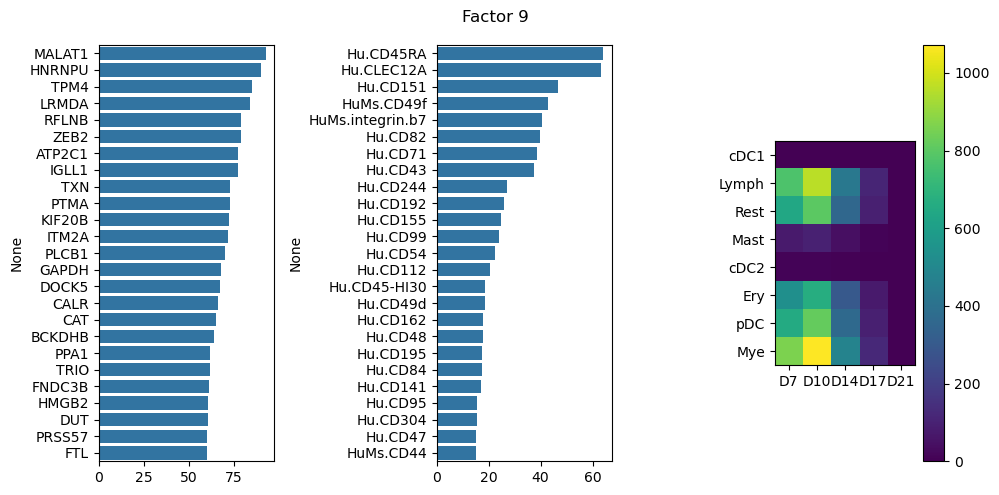

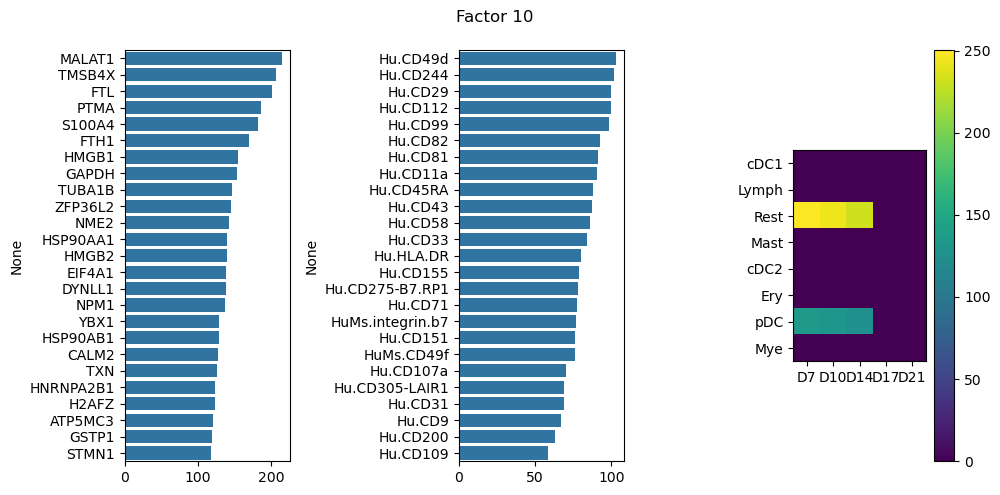

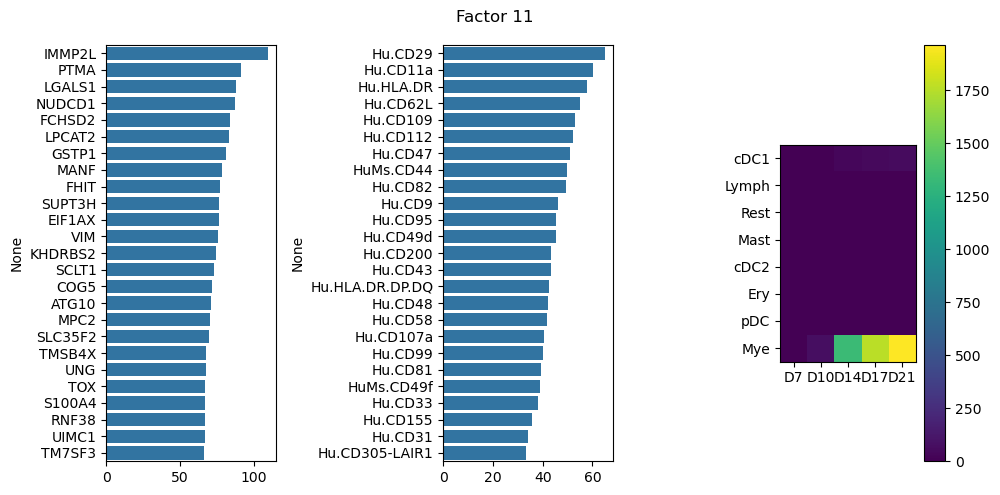

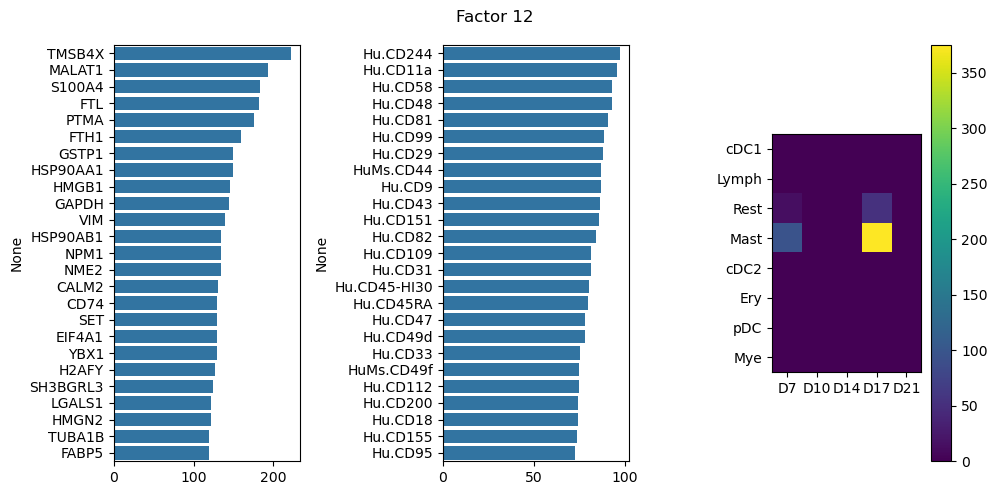

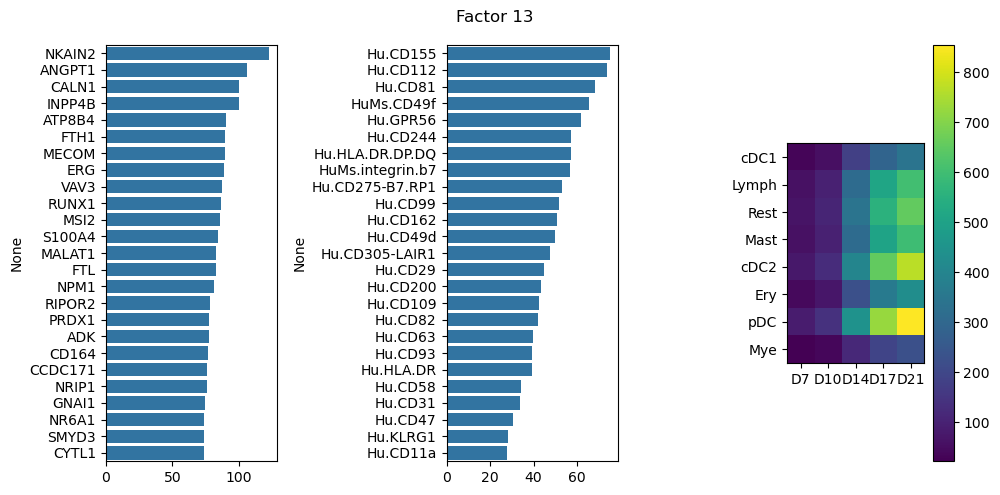

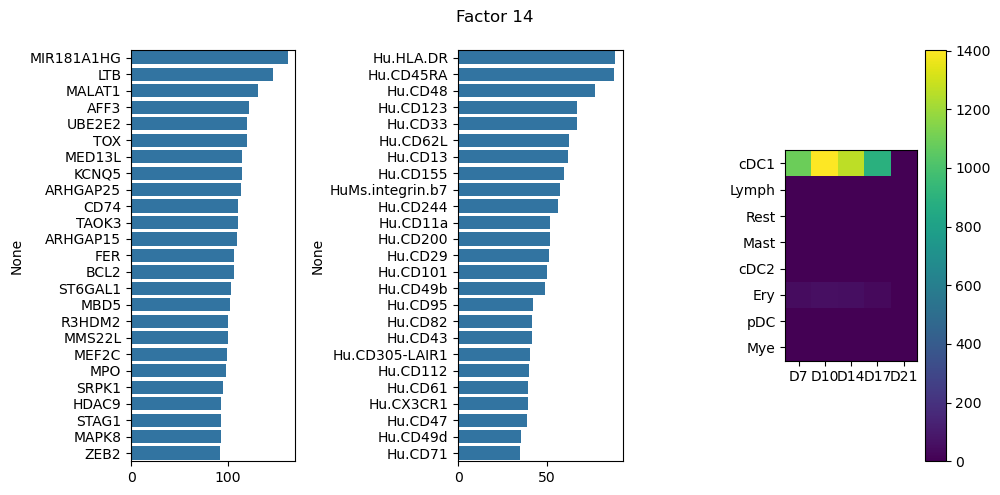

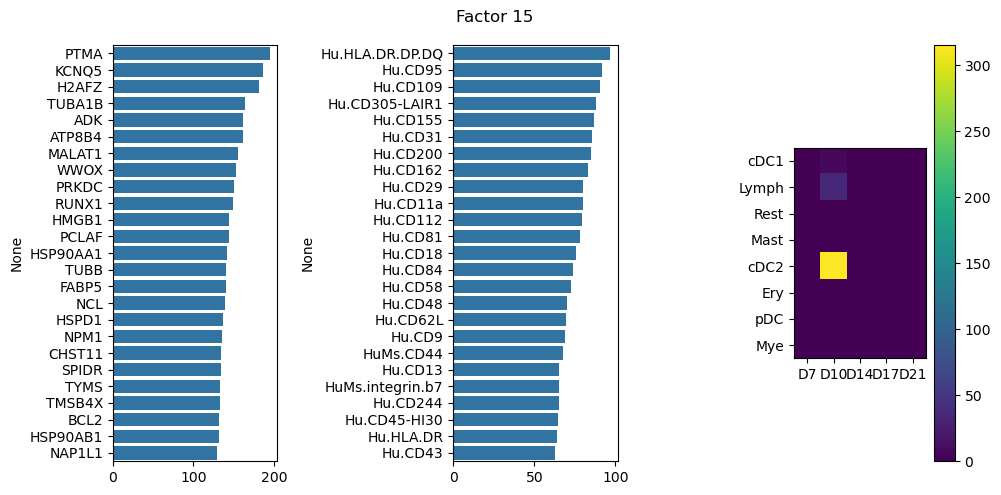

In [52]:
genes = X_rna.columns
markers = X_adt.columns
n_genes = 25
n_markers = 25
for i in range(fa_cons.k):
    plt.figure(figsize = (10, 5))
    plt.subplot(1, 3, 1)
    order = np.argsort(fa_cons.factors["Ve"][:, i])[::-1]
    sb.barplot(y = genes[order][range(n_genes)], x = fa_cons.factors["Ve"][:, i][order][range(n_genes)])
    plt.subplot(1, 3, 2)
    order = np.argsort(fa_cons.factors["Vm"][:, i])[::-1]
    sb.barplot(y = markers[order][range(n_markers)], x = fa_cons.factors["Vm"][:, i][order][range(n_markers)])
    plt.subplot(1, 3, 3)
    plt.imshow((fa_cons.factors["Vb_0"][:, i].reshape(-1, 1) @ fa_cons.factors["Vb_1"][:, i].reshape(1, -1)).T)
    plt.colorbar()
    plt.yticks(range(len(celltypes)), celltypes)
    plt.xticks(range(len(timepoints)), timepoints)
    # plt.subplot(2, 2, 4)
    # sb.scatterplot(x = X_latent_umap[:, 0], y = X_latent_umap[:, 1], hue = fa_cons.activities[:, i], palette = "viridis")
    plt.suptitle(f"Factor {i}")
    plt.tight_layout()

In [54]:
# res['cfm']
# 
# X_rna = pd.read_csv("../data/preprocessed/X_rna.csv", index_col=0)
# X_adt = pd.read_csv("../data/preprocessed/X_adt.csv", index_col=0)
# X_bc = np.load("../data/preprocessed/X_bc.npy")
# 
# k = 16
# lamda_b = 1 / np.linalg.norm(X_bc)**2
# lamda_e = 1 / np.linalg.norm(X_rna)**2
# lamda_m = 1 / np.linalg.norm(X_adt)**2
# mu_1, mu_2 = [0, 0.1, ]
# mu_lap = 0
# 
# model_params = {"params" : {"lamda_b" : lamda_b, "lamda_e" : lamda_e, "lamda_m" : lamda_m, "mu_1" : mu_1, "mu_2" : mu_2, "mu_lap" : mu_lap}, 
#                 "reg" : {"D_lap" : np.zeros((len(bc), len(bc))), "A_lap" : np.zeros((len(bc), len(bc)))}, 
#                 "iters" : 100,
#                 "normalize_activities" : False,
#                 "print_iter" : 100,
#                 "verbose" : False,
#                 "check_convergence" : 10}
# 
# n_reps = 10
# seeds = np.random.randint(0, 1_000_000, n_reps)
# cfm = consensus.ConsensusFactorModel(k = k, n_reps = n_reps, model_params = model_params, random_states = seeds)
# cfm.fit({"Xb" : X_bc, "Xe" : X_rna.to_numpy() + 1e-9, "Xm" : X_adt.to_numpy() + 1e-9})
# cfm.get_consensus_factors()
# 
# # Try prediction
# k = 16
# np.random.seed(0)
# idx = np.random.permutation(X_rna.shape[0])
# split_frac = 0.8
# idx_train = idx[range(int(split_frac*len(idx)))]
# idx_test = idx[range(int(split_frac*len(idx)), len(idx))]
# 
# from copy import copy
# model_params_ = copy(model_params)
# model_params_["reg"] = {"D_lap" : np.zeros((len(idx_train), len(idx_train))), "A_lap" : np.zeros((len(idx_train), len(idx_train)))}
# model_params_["iters"] = 1_000
# cfm = consensus.ConsensusFactorModel(k = k, n_reps = n_reps, model_params = model_params_, random_states = seeds)
# cfm.fit({"Xb" : X_bc[idx_train, :, :], "Xe" : X_rna.iloc[idx_train, :].to_numpy() + 1e-9, "Xm" : X_adt.iloc[idx_train, :].to_numpy() + 1e-9})
# cfm.get_consensus_factors()
# 
# model_params_ = copy(model_params)
# model_params_["reg"] = {"D_lap" : np.zeros((len(idx_test), len(idx_test))), "A_lap" : np.zeros((len(idx_test), len(idx_test)))}
# fa_cons = factor.LinearFactorModel(k, **model_params_)
# consensus_factors = {k : np.vstack([cfm.cons_factors[i][k] for i in range(fa_cons.k)]).T for k in cfm.factor_keys}
# fa_cons.factors = consensus_factors.copy()
# # fa_cons.fit({"Xb" : X_bc[idx_test, :, :], "Xe" : X_rna.iloc[idx_test, :].to_numpy() + 1e-9, "Xm" : X_adt.iloc[idx_test, :].to_numpy() + 1e-9});
# fa_cons.activities = fa_cons.predict_single(X_rna.iloc[idx_test, :].to_numpy() + 1e-9, what = "expr")
# 
# X_bc[0, :, :].shape
# 
# import itertools
# labels = [f"{i}-{j}" for (i, j) in list(itertools.product(celltypes, timepoints))]
# 
# cg = sb.clustermap(np.swapaxes(X_bc, 1, 2)[idx_test, :, :].reshape(len(idx_test), -1), col_cluster = False, figsize = (7.5, 5), xticklabels = labels)
# 
# sb.clustermap(np.swapaxes(fa_cons.reconstruction()['Xb'], 1, 2).reshape(len(idx_test), -1)[cg.dendrogram_row.reordered_ind, :], row_cluster = False, col_cluster = False, figsize = (7.5, 5), xticklabels = labels)